# Forecast de ingresos de peajes a nivel nacional para el 2025 y 2026 - CRISP-DM

## 01. Entendimiento del Negocio

### Objetivo

El objetivo del Actual Análisis es predecir el flujo vehicular por mes de diferentes tipos de carros, en los peajes del perú.

### KPIS de existo

Lograr construir un modelo que prediga el flujo vehicular con una exactitud mayor al 60%.

### Fuente de datos

Fuente: https://www.datosabiertos.gob.pe/dataset/flujo-vehicular-registrado-en-las-unidades-de-peaje-de-la-red-vial-nacional-2014-%E2%80%93-2025-ii

## 02. Entendimiento del Dato

### Pasos

1. Ver los primeros datos
2. Ver los ultimos datos
3. Ver de manera general ala cantidad de datos (info)
4. Ver una descripción estadistica de los datos (describe)
5. Separamos las columnas numéricas y categóricas

In [20]:
import pandas as pd

data_row = pd.read_csv('../Data/Row/Flujo vehicular registrado en peajes_2014-2025_II.csv', encoding='latin-1')

In [21]:
data_row.head(5)

,ID,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,NOMBRE_PEAJE,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,...,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,0,Concesionado,22PE5NACS1,San Martín,Aguas Claras,2099,8070.0,0,2586.0,2374.0,...,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401
1,1,Concesionado,04PE1SCAM1,Arequipa,Camaná,0,24644.0,0,6502.0,4622.0,...,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401
2,2,Concesionado,21PE3SCRO1,Puno,Caracoto,33643,82139.0,5797,17981.0,5307.0,...,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401
3,3,Concesionado,12PE3NCRA1,Junín,Casaracra-Concesión,10,46944.0,0,16981.0,18585.0,...,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401
4,4,Concesionado,08PE3SCSC1,Cusco,Ccasacancha (Huillque),0,23831.0,0,4709.0,3941.0,...,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401


In [22]:
data_row.tail(5)

,ID,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,NOMBRE_PEAJE,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,...,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
10776,10776,No concesionado,21PE36ASIC1,Puno,Sicuyani,660,3609.0,0,808.0,603.0,...,3.0,4269,142.3,5431,181.0,9700,323.3,2025,6,202506
10777,10777,No concesionado,05PE28ASOC1,Ayacucho,Socos,0,NaN,0,NaN,NaN,...,NaN,0,0.0,0,0.0,0,0.0,2025,6,202506
10778,10778,No concesionado,20PE1NLTGD1,Piura,Tambogrande,0,31078.0,0,3209.0,965.0,...,4.0,31078,1035.9,5178,172.6,36256,1208.5,2025,6,202506
10779,10779,No concesionado,15PE16TNA1,Lima,Tunán,0,NaN,0,NaN,NaN,...,NaN,0,0.0,0,0.0,0,0.0,2025,6,202506
10780,10780,No concesionado,04PE1SYCA1,Arequipa,Yauca,0,12647.0,0,4039.0,6288.0,...,302.0,12647,421.6,30766,1025.5,43413,1447.1,2025,6,202506


In [23]:
# Separamos variables categóricas de numéricas

data_row.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10781 non-null  int64  
 1   ADMINIST                 10781 non-null  object 
 2   CODIGO_PEAJE             10781 non-null  object 
 3   DEPARTAMENTO             10781 non-null  object 
 4   NOMBRE_PEAJE             10781 non-null  object 
 5   VEH_LIGEROS_TAR_DIF      10781 non-null  int64  
 6   VEH_LIGEROS_AUTOMOVILES  10768 non-null  float64
 7   VEH_PESADOS_TAR_DIF      10781 non-null  int64  
 8   VEH_PESADOS__2E          10773 non-null  float64
 9   VEH_PESADOS_3E           10773 non-null  float64
 10  VEH_PESADOS_4E           10773 non-null  float64
 11  VEH_PESADOS_5E           10773 non-null  float64
 12  VEH_PESADOS_6E           10773 non-null  float64
 13  VEH_PESADOS_7E           10773 non-null  float64
 14  VEH_LIGEROS_TOTAL     

In [24]:
data_row.describe()

,ID,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
count,10781.00000,10781.000000,10768.000000,10781.000000,10773.000000,10773.000000,10773.000000,10773.000000,10773.000000,10773.000000,10781.000000,10781.000000,10781.000000,10781.000000,1.078100e+04,10781.000000,10781.000000,10781.000000,10781.000000
mean,5390.00000,1896.093034,44374.207467,817.151841,8630.367586,7666.940685,1943.485287,2289.993874,11708.790495,162.748538,46216.792969,1521.112485,33195.434283,1092.216548,7.941223e+04,2613.362768,2019.339208,6.370281,201940.291068
std,3112.35096,6297.010934,66000.775351,2710.769041,10942.912132,9845.497573,2608.109405,3324.176873,16266.681390,391.491280,67003.821544,2206.051192,41535.153871,1364.473182,9.904596e+04,3258.058113,3.320685,3.448075,331.862137
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2014.000000,1.000000,201401.000000
25%,2695.00000,0.000000,11284.000000,0.000000,2125.000000,1300.000000,309.000000,269.000000,1728.000000,12.000000,11870.000000,393.600000,7393.000000,244.200000,2.241400e+04,739.000000,2016.000000,3.000000,201612.000000
50%,5390.00000,0.000000,23460.500000,0.000000,4218.000000,3573.000000,807.000000,808.000000,4172.000000,46.000000,24623.000000,811.100000,15964.000000,524.100000,4.208300e+04,1390.200000,2019.000000,6.000000,201911.000000
75%,8085.00000,376.000000,47658.250000,0.000000,10589.000000,8678.000000,2486.000000,2817.000000,15900.000000,192.000000,50025.000000,1644.200000,40611.000000,1335.700000,9.940700e+04,3282.100000,2022.000000,9.000000,202209.000000
max,10780.00000,71734.000000,796486.000000,38818.000000,73590.000000,78943.000000,25137.000000,25361.000000,99895.000000,21799.000000,796486.000000,27914.100000,241058.000000,8440.800000,1.037544e+06,35023.400000,2025.000000,12.000000,202506.000000


In [25]:
(data_row.isnull().sum()/data_row.count())*100 # vemos el porcentaje de nulos que tiene la información.

ID                         0.000000
ADMINIST                   0.000000
CODIGO_PEAJE               0.000000
DEPARTAMENTO               0.000000
NOMBRE_PEAJE               0.000000
VEH_LIGEROS_TAR_DIF        0.000000
VEH_LIGEROS_AUTOMOVILES    0.120728
VEH_PESADOS_TAR_DIF        0.000000
VEH_PESADOS__2E            0.074260
VEH_PESADOS_3E             0.074260
VEH_PESADOS_4E             0.074260
VEH_PESADOS_5E             0.074260
VEH_PESADOS_6E             0.074260
VEH_PESADOS_7E             0.074260
VEH_LIGEROS_TOTAL          0.000000
VEH_LIGEROS_IMD            0.000000
VEH_PESADOS_TOTAL          0.000000
VEH_PESADOS_IMD            0.000000
VEH_TOTAL                  0.000000
VEH_IMD                    0.000000
ANIO                       0.000000
MES                        0.000000
PERIODO                    0.000000
dtype: float64

In [26]:
# Separamos variables numéricas de categóricas.

col_df_num = data_row.select_dtypes(include=['number', 'float64', 'int64']).columns
col_df_cat = data_row.select_dtypes(include=['object', 'category']).columns

In [27]:
col_df_num

Index(['ID', 'VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES',
       'VEH_PESADOS_TAR_DIF', 'VEH_PESADOS__2E', 'VEH_PESADOS_3E',
       'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E', 'VEH_PESADOS_7E',
       'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD', 'VEH_PESADOS_TOTAL',
       'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD', 'ANIO', 'MES', 'PERIODO'],
      dtype='object')

In [28]:
col_df_cat

Index(['ADMINIST', 'CODIGO_PEAJE', 'DEPARTAMENTO', 'NOMBRE_PEAJE'], dtype='object')

In [53]:
df_processed = data_row.copy()
df_processed['PERIODO'] = pd.to_datetime(data_row['PERIODO'], format='%Y%m')

df_processed['CODIGO_PEAJE'].unique()

array(['22PE5NACS1', '04PE1SCAM1', '21PE3SCRO1', '12PE3NCRA1',
       '08PE3SCSC1', '13PE1NCMA1', '15PE1SCLA1', '20PE1NJCLS1',
       '13PE08CDS1', '15PE22CCA1', '20PE1NCBA1', '14PE04BOLS1',
       '04PE1SEFS1', '15PE1NEPS1', '15PE1NFZA1', '02PE1NHUY1',
       '11PE1SICA1', '18PE36ILO1', '11PE1SJAY1', '20PE02ALLA1',
       '21PE34BMNI1', '11PE30MNA1', '04PE34MRI1', '13PE10AMEO1',
       '14PE1NJMOC1', '18PE1SMTV1', '14PE1NMRE1', '22PE5NMYB1',
       '13PE1NPGA1', '20PE02PAI1', '18PE36APCL1', '05PE30APGR1',
       '03PE30APPR1', '04PE34APTI1', '01PE08CPRS1', '03PE30APRH1',
       '20PE1NPSA1', '17PE30CPNN1', '06PE3NPPU1', '22PE5NBPGO1',
       '12PE3SQLA1', '21PE34BSGB1', '17PE30CSLZ1', '21PE34ASLA1',
       '15PE1NASPY1', '23PE1STMS1', '04PE34AVYO1', '17PE30CUPO1',
       '01PE5NUTB1', '15PE1NVPY1', '02PE1NVSQ1', '13PE1NVIR1',
       '08PE3SACS1', '04PE1SATI1', '21PE3SAYV1', '24PE1NCCS1',
       '02PE3NCTC1', '12PE3SHUO1', '12PE22BCHO1', '14PE06ACUC1',
       '20PE1NTYL1', '21PE3SILV1'

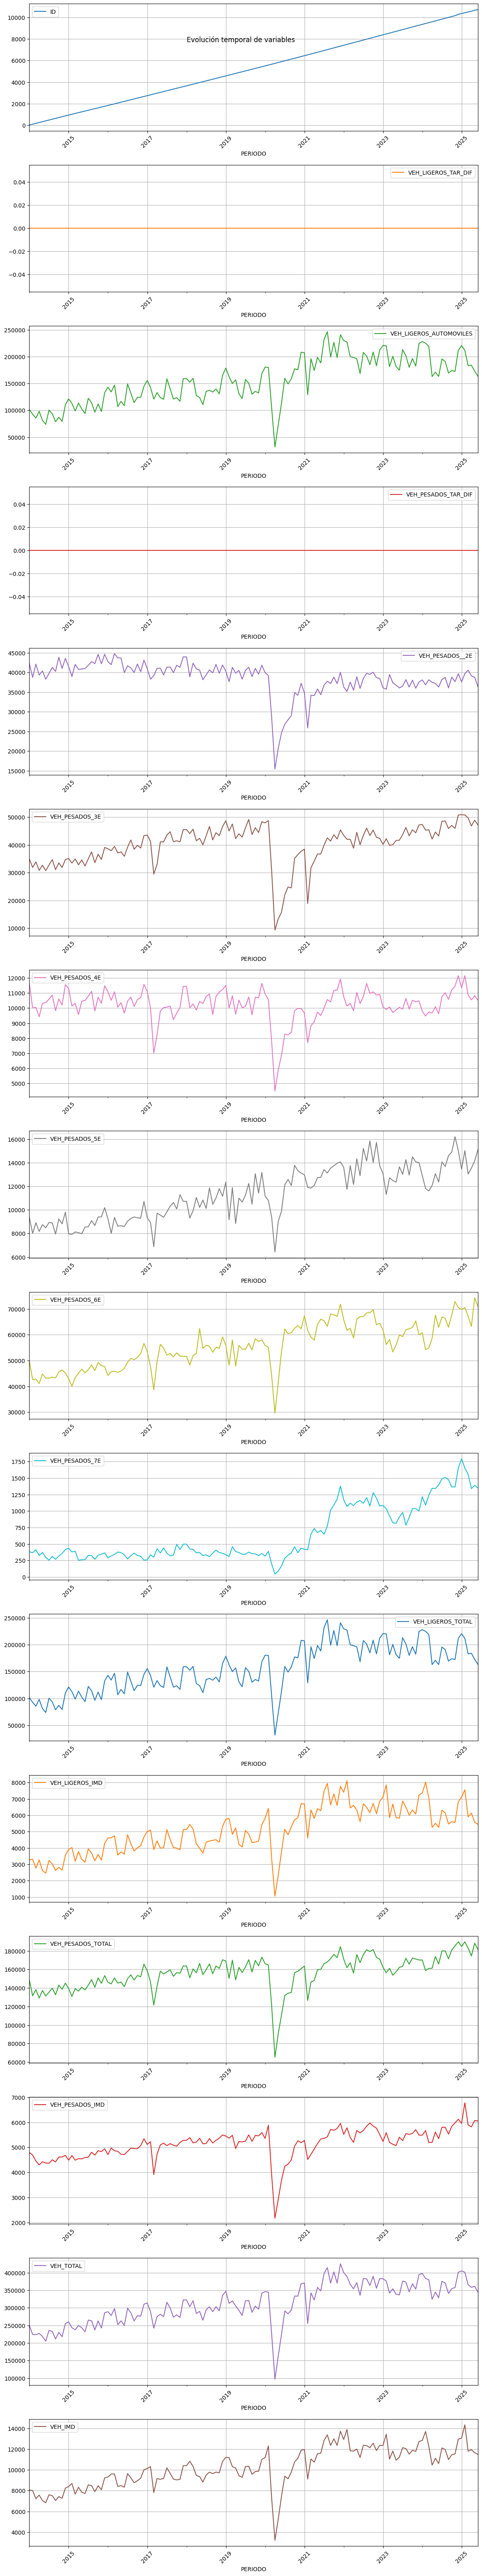

In [68]:
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

vars_a_graficar = [val for val in col_df_num if val not in ('PERIODO', 'ANIO', 'MES')]
num_vars = len(vars_a_graficar)

peaje = '15PE1NEPS1'

df_processed[df_processed['CODIGO_PEAJE'] == peaje].plot(
    x='PERIODO',
    y=vars_a_graficar,
    subplots=True,
    layout=(num_vars, 1),
    figsize=(12, 4*num_vars),
    sharex=False,
    title="Evolución temporal de variables",
    grid=True,
    rot=45
)

plt.tight_layout()


array([[<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>],
       [<AxesSubplot: xlabel='PERIODO'>]], dtype=object)

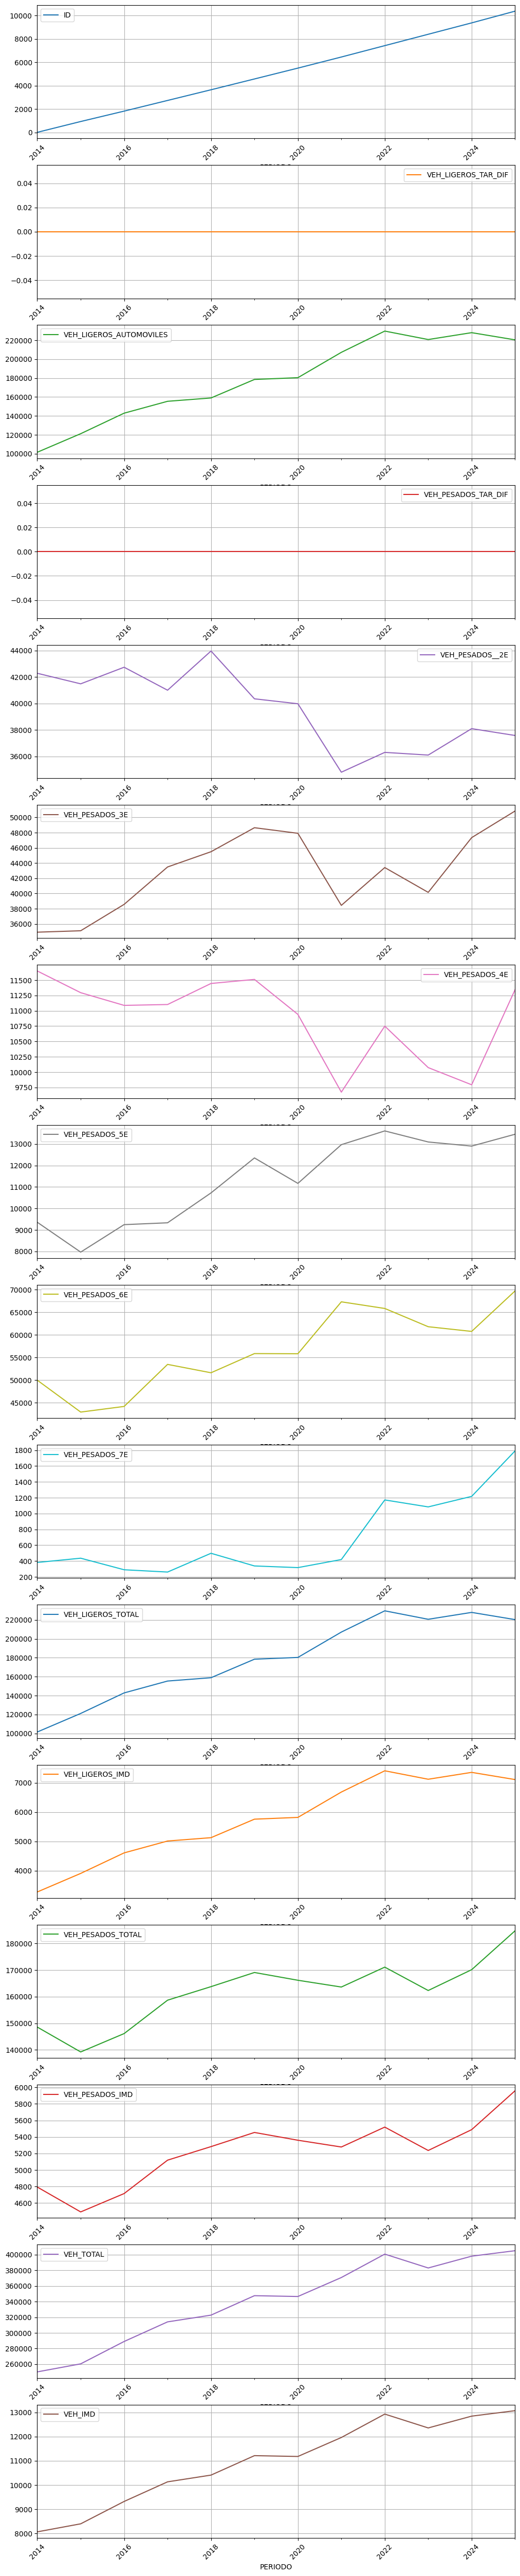

In [69]:
df_processed[(df_processed['CODIGO_PEAJE'] == peaje) & (df_processed['MES'] == 1)].plot(
    x='PERIODO',
    y=vars_a_graficar,
    subplots=True,
    layout=(num_vars, 1),
    figsize=(12, 4*num_vars),
    sharex=False,
    grid=True,
    rot=45
)

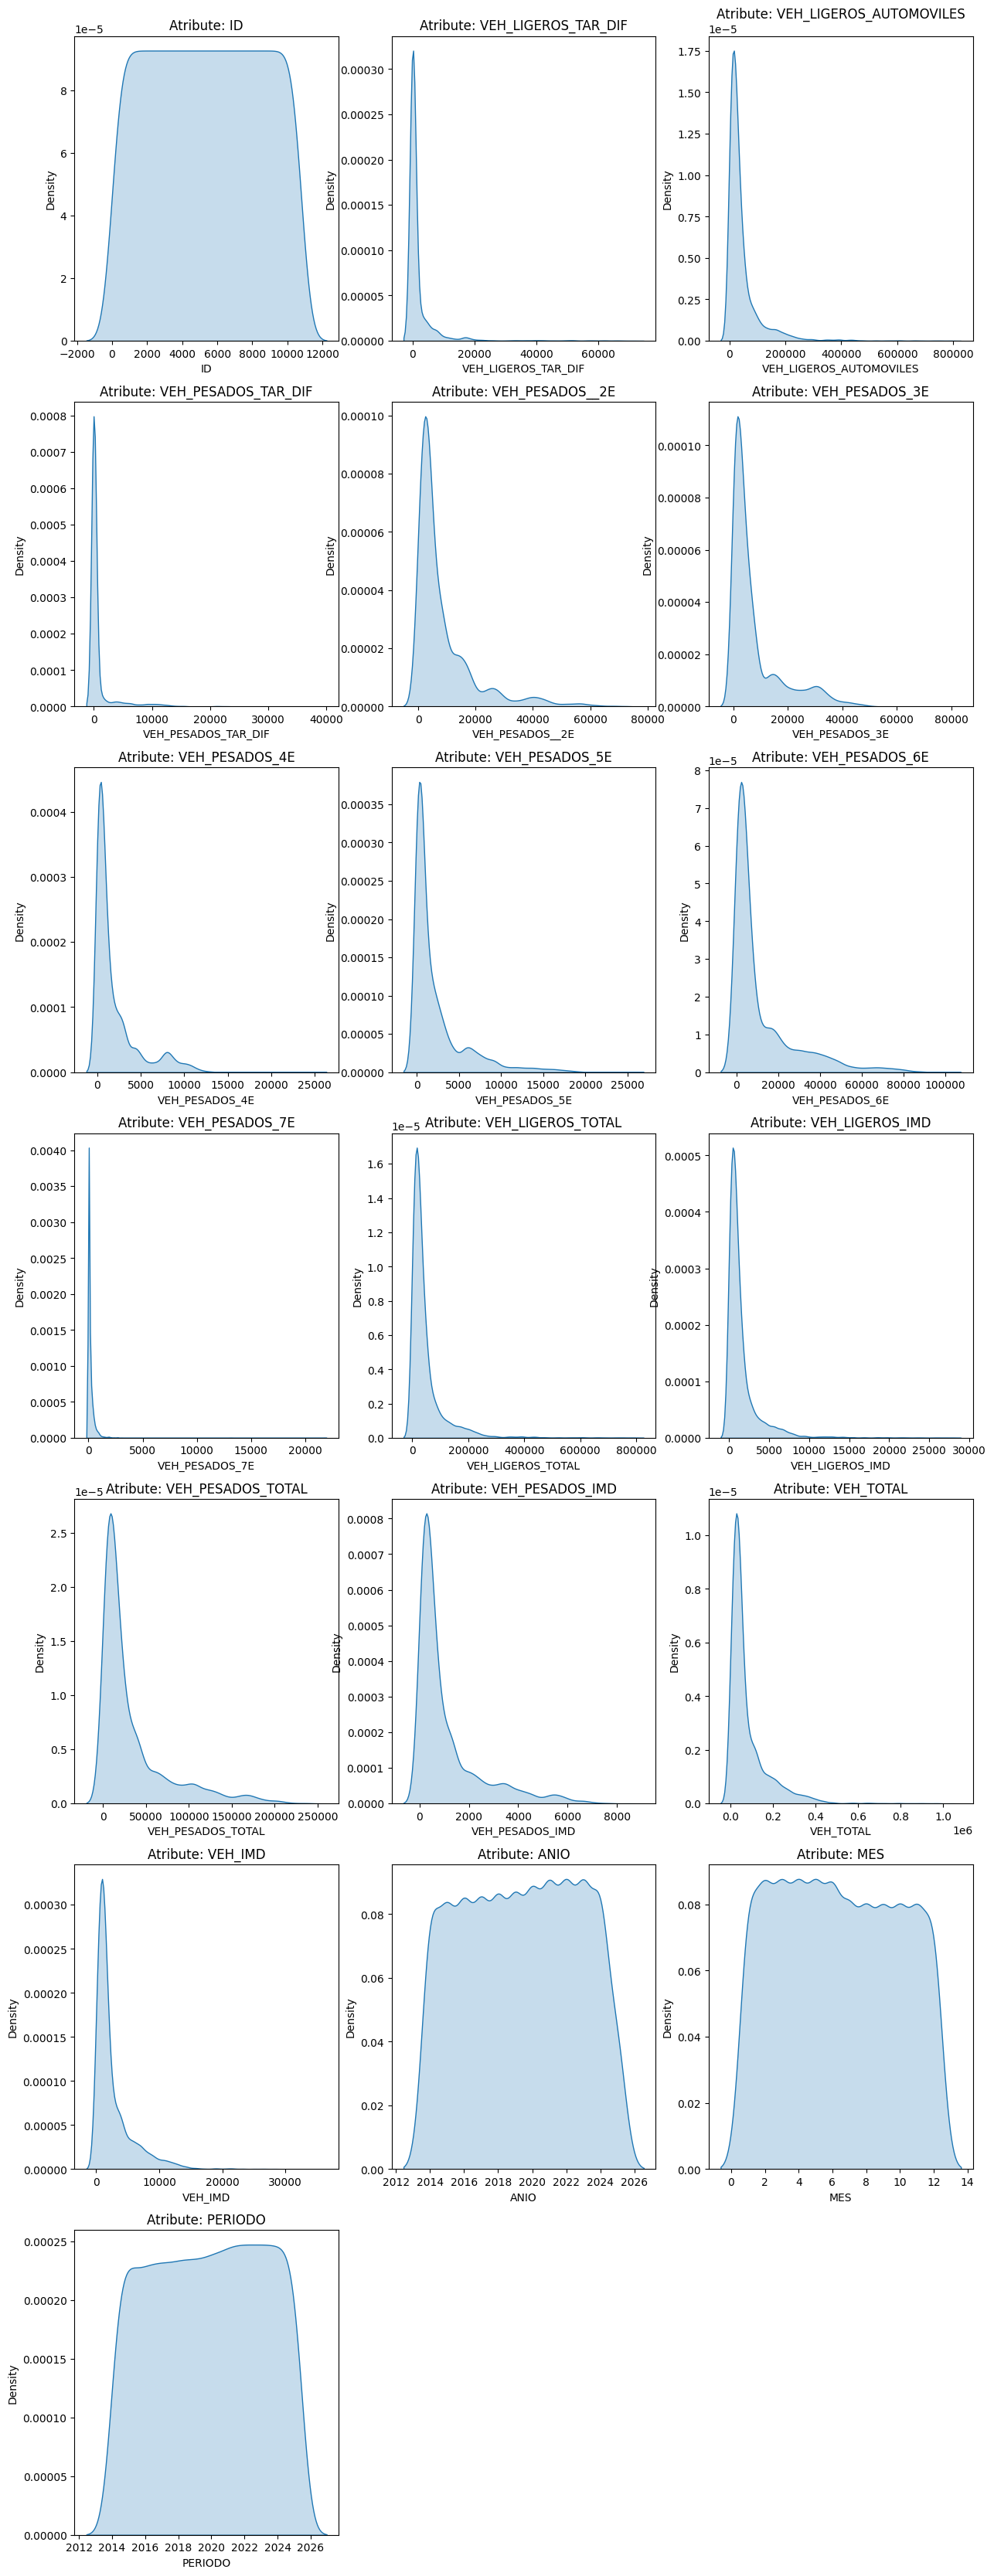

In [74]:
import seaborn as sns
import math

n_vars = len(col_df_num)
n_cols = 3

n_rows = math.ceil(n_vars / n_cols)

plt.figure(figsize=(15, 6*n_rows))

for i, atribute in enumerate(col_df_num):
    plt.subplot(n_rows, n_cols, i+1)
    sns.kdeplot(df_processed[atribute], fill=True)
    plt.title(f"Atribute: {atribute}")
    plt.xlabel(atribute)
    plt.ylabel('Density')


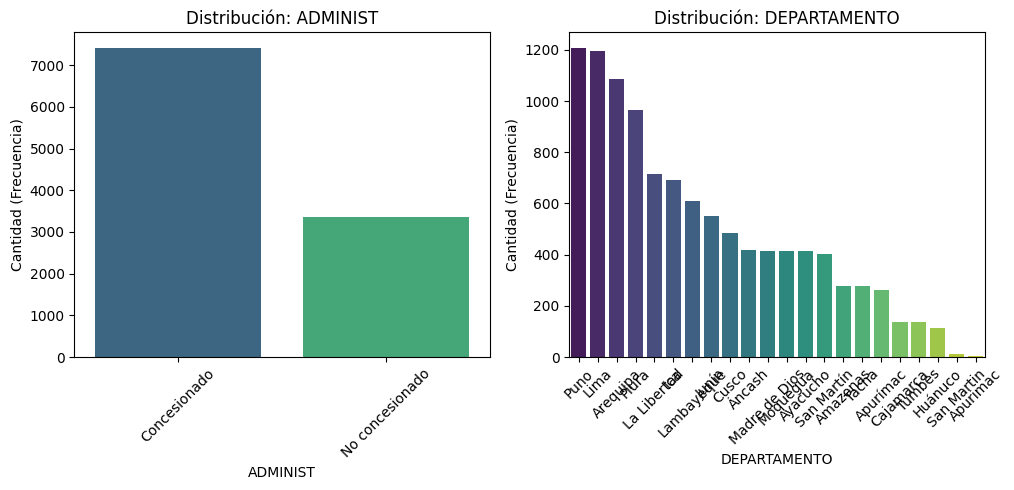

In [78]:

import matplotlib.pyplot as plt
import seaborn as sns
import math

# Asumiendo que tienes una lista de tus variables categóricas
# col_df_cat = ['Genero', 'Ciudad', 'Educacion', ...] 

col_df_cat_2 = [v for v in col_df_cat if v not in ('CODIGO_PEAJE', 'NOMBRE_PEAJE')]

n_vars = len(col_df_cat_2)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

plt.figure(figsize=(15, 5 * n_rows)) # Aumenté un poco la altura por fila

for i, attribute in enumerate(col_df_cat_2):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # --- CAMBIO PRINCIPAL ---
    # Usamos countplot en lugar de kdeplot
    # order: Ordena las barras de la más frecuente a la menos frecuente
    sns.countplot(
        x=df_processed[attribute], 
        order=df_processed[attribute].value_counts().index,
        palette='viridis' # Opcional: añade color
    )
    # ------------------------
    
    plt.title(f"Distribución: {attribute}")
    plt.xlabel(attribute)
    plt.ylabel('Cantidad (Frecuencia)')
    
    # Rotamos 45 grados las etiquetas del eje X para que se lean bien
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()